In [22]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display



In [23]:
def process_audio_files(file_paths):
    waveforms = []
    mel_spectrograms_db = []
    sample_rates = []
    file_names = [path.split('/')[-1] for path in file_paths]

    for file_path in file_paths:
        # Load the audio file
        audio_data, sample_rate = librosa.load(file_path, sr=None)
        waveforms.append(audio_data)
        sample_rates.append(sample_rate)

        # Convert to Mel-Spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate, n_mels=128)
        mel_spectrograms_db.append(librosa.power_to_db(mel_spectrogram, ref=np.max))

    # Plot all waveforms
    plt.figure(figsize=(15, len(file_paths) * 3))
    for i, (audio_data, sr, name) in enumerate(zip(waveforms, sample_rates, file_names)):
        plt.subplot(len(file_paths), 1, i + 1)
        librosa.display.waveshow(audio_data, sr=sr)
        plt.title(f"Waveform of {name}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # Plot all Mel-Spectrograms
    plt.figure(figsize=(15, len(file_paths) * 4))
    for i, (mel_db, sr, name) in enumerate(zip(mel_spectrograms_db, sample_rates, file_names)):
        plt.subplot(len(file_paths), 1, i + 1)
        librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Mel-Spectrogram of {name}")
    plt.tight_layout()
    plt.show()

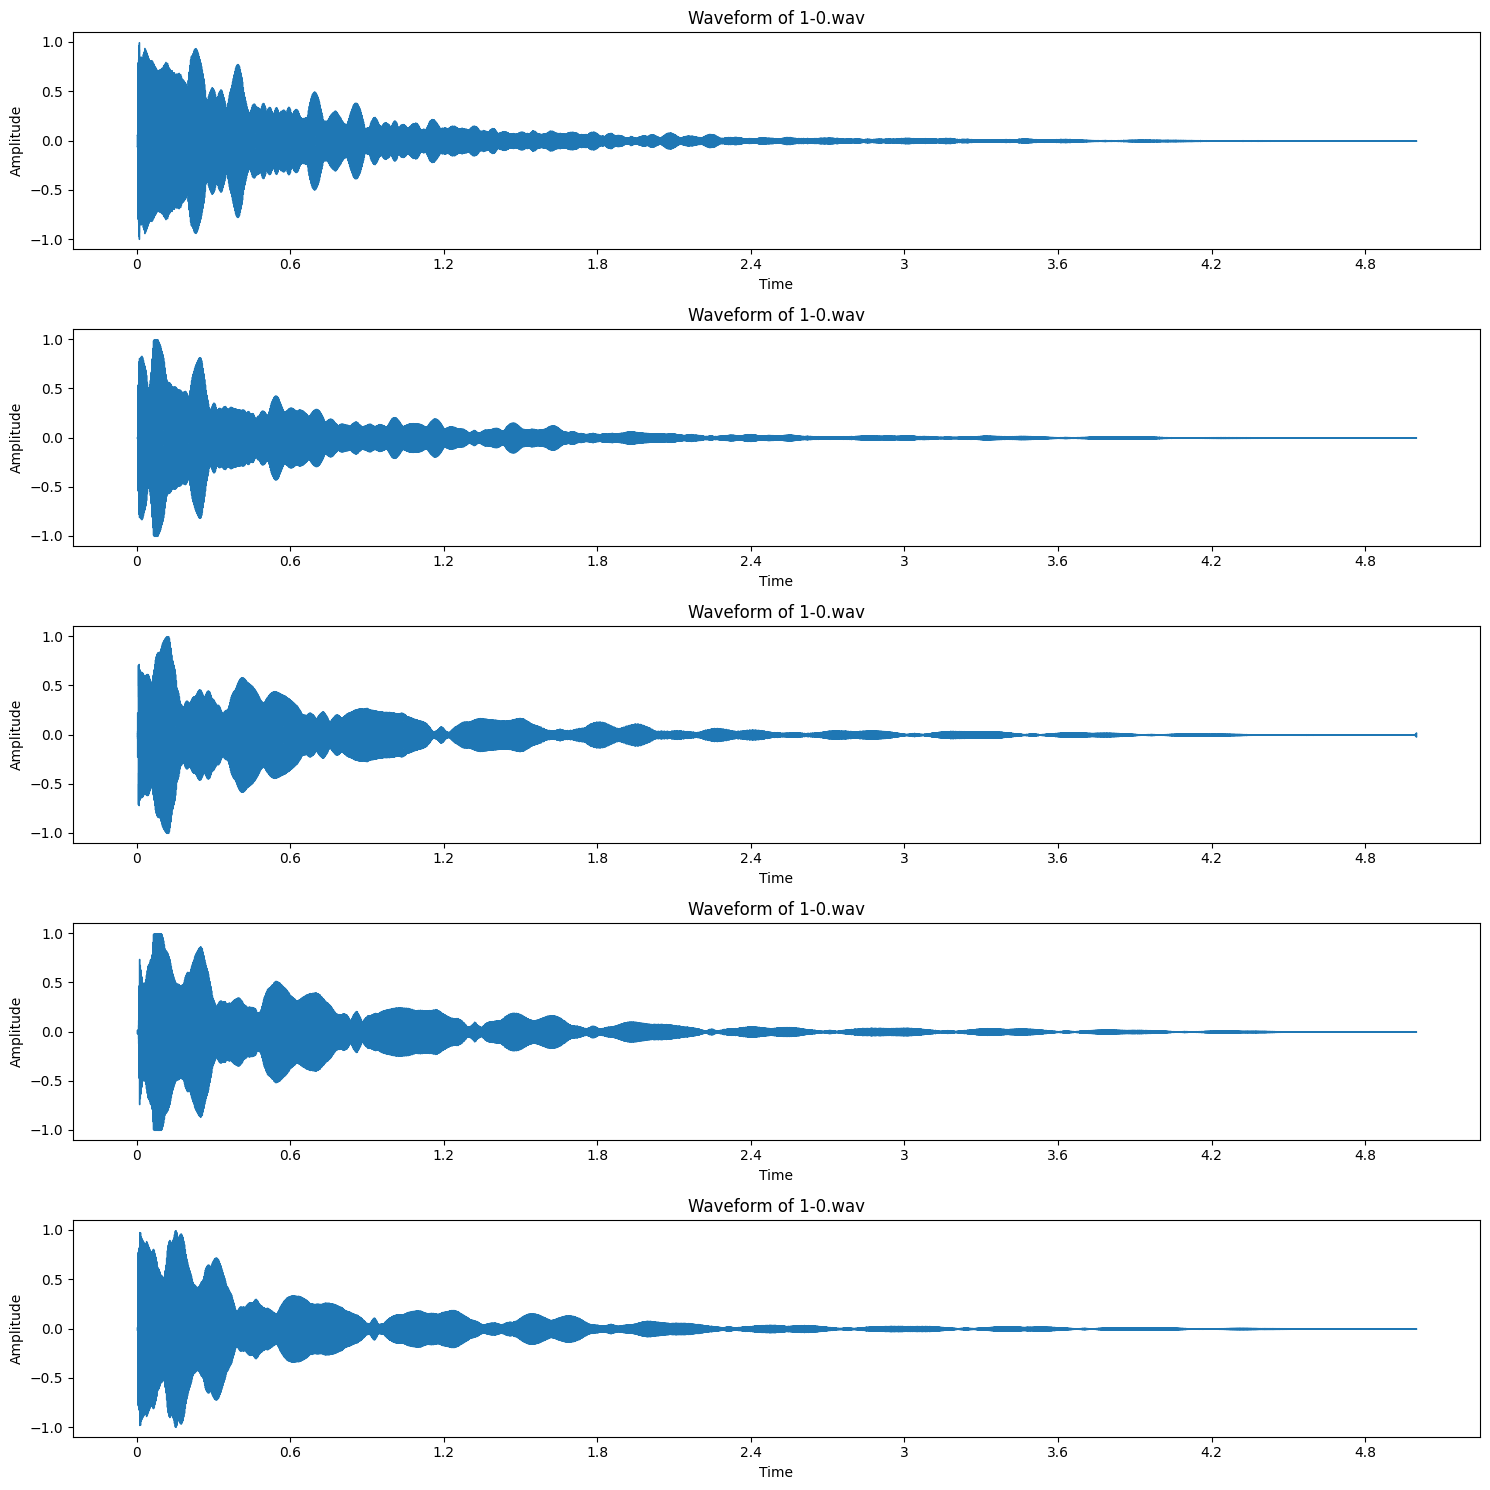

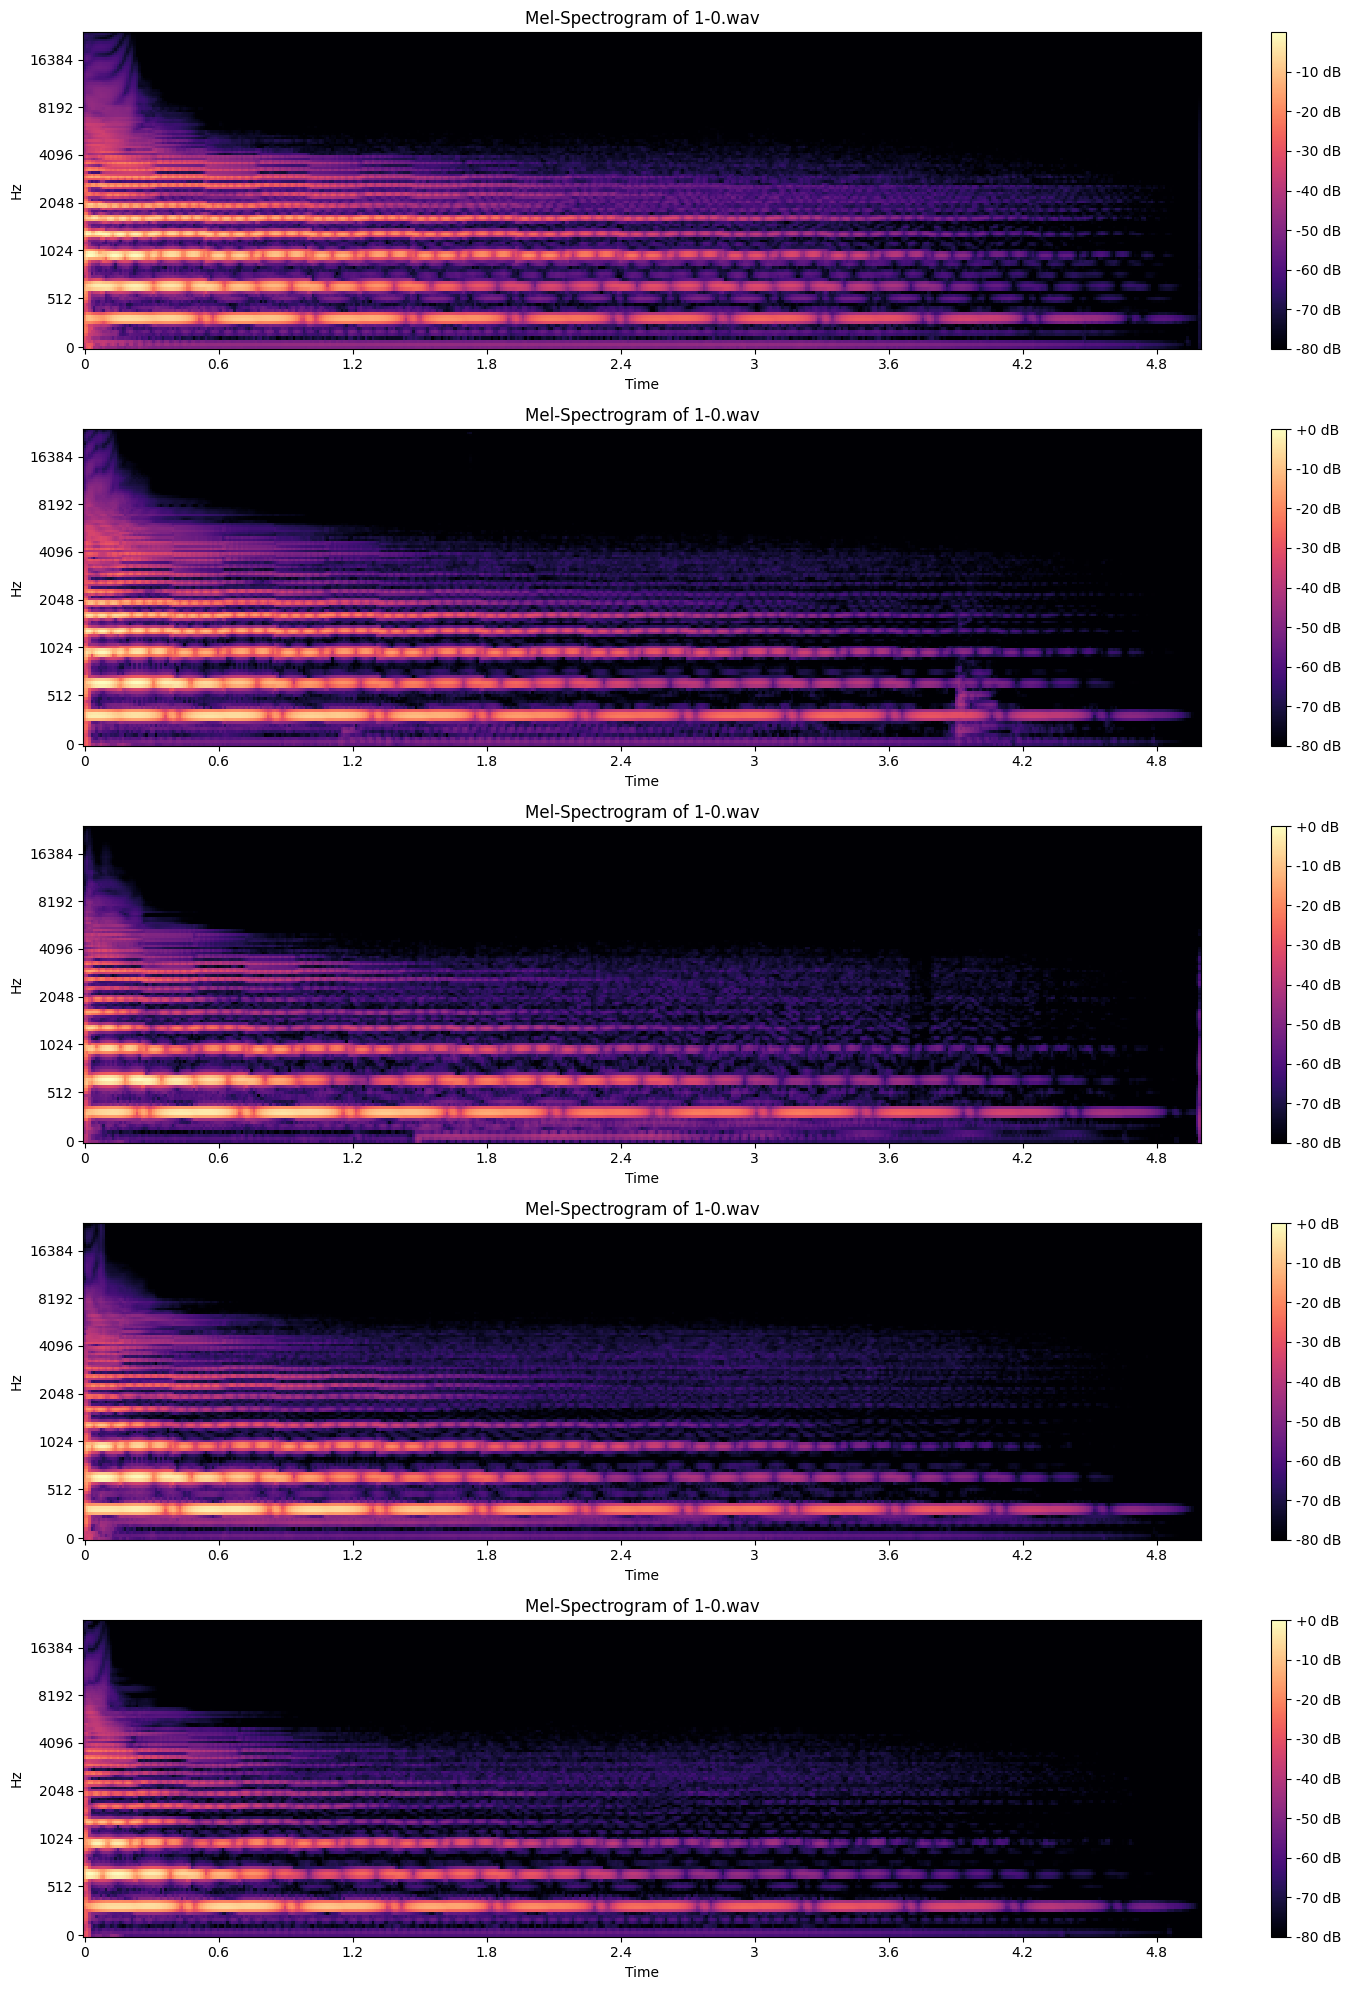

In [25]:
# List of audio file paths
file_paths = [
    '../data/Chorus/Chorus/Bridge/1-0.wav',
    '../data/Chorus/Chorus/Bridge-Middle/1-0.wav',
    '../data/Chorus/Chorus/Middle/1-0.wav',
    '../data/Chorus/Chorus/Middle-Neck/1-0.wav',
    '../data/Chorus/Chorus/Neck/1-0.wav',  # Add more file paths as needed
]

# Process the audio files
process_audio_files(file_paths)